In [1]:
## importing libaries
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np


In [ ]:
## Load both CSV files 
df1 = pd.read_csv('prompt_evaluation_dataset.csv')
df2 = pd.read_csv('prompt_evaluation_training_data.csv')

# Combine into one unified dataframe and reset the index
df = pd.concat([df1, df2], ignore_index=True)

print(f'File 1 shape  : {df1.shape}')
print(f'File 2 shape  : {df2.shape}')
print(f'Combined shape: {df.shape}')

File 1 shape  : (10000, 12)
File 2 shape  : (10000, 12)
Combined shape: (20000, 12)


In [ ]:
## Look at the first few rows of the combined dataframe
df.head(2)

,id,task_type,prompt,quality_level,quality_score,grade,hallucination_risk,clarity,specificity,structure,constraints,decisions
0,1,post,post about analyze supply chain efficiency,low,60,D,0.73,1,1,2,1,Insufficient detail for execution | No constra...
1,2,code,develop risk assessment framework script neede...,low,52,F,0.66,2,2,2,2,Unprofessional presentation | No context provi...


In [ ]:
## Getting Information about column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20000 non-null  int64  
 1   task_type           20000 non-null  str    
 2   prompt              20000 non-null  str    
 3   quality_level       20000 non-null  str    
 4   quality_score       20000 non-null  int64  
 5   grade               20000 non-null  str    
 6   hallucination_risk  20000 non-null  float64
 7   clarity             20000 non-null  int64  
 8   specificity         20000 non-null  int64  
 9   structure           20000 non-null  int64  
 10  constraints         20000 non-null  int64  
 11  decisions           20000 non-null  str    
dtypes: float64(1), int64(6), str(5)
memory usage: 8.1 MB


In [ ]:
## The Statistics of the dataset
df.describe()

,id,quality_score,hallucination_risk,clarity,specificity,structure,constraints
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,55000.500000,72.913300,0.427919,3.210350,3.154650,3.154350,3.056550
std,50084.516132,20.119774,0.230070,1.267511,1.322732,1.318716,1.270367
min,1.000000,20.000000,0.050000,1.000000,1.000000,1.000000,1.000000
25%,5000.750000,64.750000,0.230000,2.000000,2.000000,2.000000,2.000000
50%,55000.500000,77.000000,0.400000,3.000000,3.000000,3.000000,3.000000
75%,105000.250000,89.000000,0.570000,4.000000,4.000000,4.000000,4.000000
max,110000.000000,100.000000,0.950000,5.000000,5.000000,5.000000,5.000000


In [ ]:
##Checking for missing values
df.isnull().sum()

id                    0
task_type             0
prompt                0
quality_level         0
quality_score         0
grade                 0
hallucination_risk    0
clarity               0
specificity           0
structure             0
constraints           0
decisions             0
dtype: int64

In [ ]:
## Now checking for duplicates rows 
df.duplicated().sum()

np.int64(0)

There is no missing values as well as no duplicates. 

The only row we gonna remove is of id as it is same as index.

In [ ]:
df_copy = df.copy() ## Creating a copy of the original dataframe to work with

In [ ]:
df_copy.drop(columns=['id'], inplace=True) ## Dropping the 'id' column as it is not useful for analysis

In [ ]:
df_copy.shape ## This is our dataset shape

(20000, 11)

In [ ]:
## Finding the number of categorical and numerical columns
categorical_cols = df_copy.select_dtypes(include=['object']).columns
numerical_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns: 5
Index(['task_type', 'prompt', 'quality_level', 'grade', 'decisions'], dtype='str')

Numerical columns: 6
Index(['quality_score', 'hallucination_risk', 'clarity', 'specificity',
       'structure', 'constraints'],
      dtype='str')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27064\1250280383.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_copy.select_dtypes(include=['object']).columns


In [ ]:
## Finding outliers using the IQR method for each numerical column rounding upto 2 decimal places
outlier_records = [] 
for col in numerical_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR     ## Lower Fence
    upper  = Q3 + 1.5 * IQR     ## Upper Fence
    n_out  = ((df_copy[col] < lower) | (df[col] > upper)).sum()
    outlier_records.append({
        'Column': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2),     
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outliers': n_out
    })

display(pd.DataFrame(outlier_records).set_index('Column'))

,Q1,Q3,Lower Fence,Upper Fence,Outliers
Column,,,,,
quality_score,64.75,89.00,28.38,125.38,763
hallucination_risk,0.23,0.57,-0.28,1.08,0
clarity,2.00,4.00,-1.00,7.00,0
specificity,2.00,4.00,-1.00,7.00,0
structure,2.00,4.00,-1.00,7.00,0
constraints,2.00,4.00,-1.00,7.00,0


In [ ]:
## Applying ordinal dtypes to the 'grade' and 'quality_level' columns
df_copy['grade'] = pd.Categorical(
    df_copy['grade'], categories=['F', 'D', 'C', 'B', 'A'], ordered=True)

df_copy['quality_level'] = pd.Categorical(
    df_copy['quality_level'], categories=['low', 'medium', 'high'], ordered=True)

print('Ordinal dtypes applied.')
print('grade dtype        :', df_copy['grade'].dtype)
print('quality_level dtype:', df_copy['quality_level'].dtype)
print(f'\nFinal cleaned dataset shape: {df_copy.shape}')
df_copy.head(3)

Ordinal dtypes applied.
grade dtype        : category
quality_level dtype: category

Final cleaned dataset shape: (20000, 11)


,task_type,prompt,quality_level,quality_score,grade,hallucination_risk,clarity,specificity,structure,constraints,decisions
0,post,post about analyze supply chain efficiency,low,60,D,0.73,1,1,2,1,Insufficient detail for execution | No constra...
1,code,develop risk assessment framework script neede...,low,52,F,0.66,2,2,2,2,Unprofessional presentation | No context provi...
2,presentation,Need a deck on develop project timeline for de...,medium,77,C,0.54,4,3,4,3,Understandable intent | Structure inconsistent...


<a id='4'></a>
## Feature Engineering

We derive new, more informative features from the raw columns to unlock deeper insights.



In [ ]:
## Prompt text features
df_copy['prompt'].unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      'post about analyze supply chain efficiency',
                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
## Finding the prompt length and word count in it 
df_copy['prompt_length']     = df_copy['prompt'].str.len()
df_copy['prompt_word_count'] = df_copy['prompt'].str.split().str.len()

In [ ]:
# ── Step 1: Normalize rating features (1–5 → 0–1) ───────────────────────────
rating_cols = ['clarity', 'specificity', 'structure', 'constraints']
for col in rating_cols:
    df_copy[col + '_norm'] = df_copy[col] / 5


# ── Step 2: Data-driven weights from correlation with quality_score ──────────
# Actual correlations: structure=0.7934, specificity=0.7911, constraints=0.7590, clarity=0.7492
raw_weights = {'clarity': 0.7492, 'specificity': 0.7911, 'structure': 0.7934, 'constraints': 0.7590}
total = sum(raw_weights.values())
w = {k: round(v / total, 4) for k, v in raw_weights.items()}
# Result: clarity=0.2424, specificity=0.2561, structure=0.2568, constraints=0.2457
# (all roughly equal — data says all 4 features matter similarly)

df_copy['base_score'] = (
    w['clarity']      * df_copy['clarity_norm'] +
    w['specificity']  * df_copy['specificity_norm'] +
    w['structure']    * df_copy['structure_norm'] +
    w['constraints']  * df_copy['constraints_norm']
)


# ── Step 3: Stronger hallucination penalty (0.5 instead of 0.3) ─────────────
df_copy['raw_score'] = (
    df_copy['base_score'] * (1 - 0.5 * df_copy['hallucination_risk'])
)


# ── Step 4: Save scaler params from TRAIN SET ONLY (fix leakage) ────────────
# Do your train/test split BEFORE this step in actual model pipeline
# Here we compute on full data just for dataset creation — flag this in paper
score_min = df_copy['raw_score'].min()
score_max = df_copy['raw_score'].max()

df_copy['normalized_score'] = (
    (df_copy['raw_score'] - score_min) /
    (score_max - score_min)
)

# Store these values — use them later on test set
print(f"Scaler params to reuse → min: {score_min:.6f}, max: {score_max:.6f}")


# ── Step 5: Convert to 20–100 scale ─────────────────────────────────────────
df_copy['custom_score_100'] = (
    df_copy['normalized_score'] * 80 + 20
).round(2)


# ── Step 6: Assign grades ────────────────────────────────────────────────────
def assign_grade(score):
    if score >= 85:
        return 'A'
    elif score >= 70:
        return 'B'
    elif score >= 55:
        return 'C'
    elif score >= 40:
        return 'D'
    else:
        return 'F'

df_copy['custom_grade'] = df_copy['custom_score_100'].apply(assign_grade)


# ── Step 7: Ordered categorical ──────────────────────────────────────────────
df_copy['custom_grade'] = pd.Categorical(
    df_copy['custom_grade'],
    categories=['F', 'D', 'C', 'B', 'A'],
    ordered=True
)


# ── Final Check ──────────────────────────────────────────────────────────────
print(df_copy[['base_score', 'raw_score', 'custom_score_100', 'custom_grade']].describe())
print("\nGrade distribution:")
print(df_copy['custom_grade'].value_counts().sort_index())
print("\nCustom score by quality_level:")
print(df_copy.groupby('quality_level')['custom_score_100'].mean())

Scaler params to reuse → min: 0.104990, max: 0.974903
         base_score     raw_score  custom_score_100
count  20000.000000  20000.000000      20000.000000
mean       0.628735      0.506632         56.936353
std        0.230799      0.222321         20.445346
min        0.199980      0.104990         20.000000
25%        0.448400      0.345965         42.160000
50%        0.646160      0.489065         55.320000
75%        0.851080      0.719928         76.550000
max        0.999900      0.974903        100.000000

Grade distribution:
custom_grade
F    4672
D    5159
C    4401
B    3416
A    2352
Name: count, dtype: int64

Custom score by quality_level:
quality_level
low       30.650894
medium    53.434173
high      79.714173
Name: custom_score_100, dtype: float64


In [ ]:
df_copy.head(2)

,task_type,prompt,quality_level,quality_score,grade,hallucination_risk,clarity,specificity,structure,constraints,...,prompt_word_count,clarity_norm,specificity_norm,structure_norm,constraints_norm,base_score,raw_score,normalized_score,custom_score_100,custom_grade
0,post,post about analyze supply chain efficiency,low,60,D,0.73,1,1,2,1,...,6,0.2,0.2,0.4,0.2,0.25128,0.159563,0.062734,25.02,F
1,code,develop risk assessment framework script neede...,low,52,F,0.66,2,2,2,2,...,7,0.4,0.4,0.4,0.4,0.39996,0.267973,0.187356,34.99,F


In [ ]:
df_copy['custom_score_100'].min()

np.float64(20.0)

In [ ]:
df_copy['custom_score_100'].max()

np.float64(100.0)

In [ ]:
df_copy['clarity'].unique()

array([1, 2, 4, 5, 3])

In [ ]:
df_copy['structure'].unique()

array([2, 4, 3, 5, 1])

In [ ]:
df_copy['constraints'].unique()

array([1, 2, 3, 4, 5])

In [ ]:
df_copy['hallucination_risk'].unique()

array([0.73, 0.66, 0.54, 0.33, 0.15, 0.21, 0.65, 0.69, 0.88, 0.82, 0.36,
       0.85, 0.44, 0.46, 0.17, 0.68, 0.81, 0.3 , 0.4 , 0.08, 0.13, 0.24,
       0.49, 0.2 , 0.16, 0.5 , 0.32, 0.18, 0.12, 0.9 , 0.63, 0.53, 0.61,
       0.52, 0.51, 0.19, 0.06, 0.09, 0.77, 0.48, 0.22, 0.86, 0.14, 0.41,
       0.45, 0.47, 0.23, 0.92, 0.35, 0.72, 0.87, 0.94, 0.74, 0.79, 0.37,
       0.91, 0.07, 0.84, 0.43, 0.75, 0.31, 0.7 , 0.6 , 0.42, 0.78, 0.38,
       0.05, 0.11, 0.1 , 0.34, 0.25, 0.89, 0.8 , 0.76, 0.95, 0.67, 0.39,
       0.64, 0.62, 0.55, 0.83, 0.93, 0.71, 0.27, 0.29, 0.26, 0.59, 0.58,
       0.56, 0.28, 0.57])

In [ ]:
df.columns.tolist()

['id',
 'task_type',
 'prompt',
 'quality_level',
 'quality_score',
 'grade',
 'hallucination_risk',
 'clarity',
 'specificity',
 'structure',
 'constraints',
 'decisions']

In [ ]:
df_copy.columns.tolist()

['task_type',
 'prompt',
 'quality_level',
 'quality_score',
 'grade',
 'hallucination_risk',
 'clarity',
 'specificity',
 'structure',
 'constraints',
 'decisions',
 'prompt_length',
 'prompt_word_count',
 'clarity_norm',
 'specificity_norm',
 'structure_norm',
 'constraints_norm',
 'base_score',
 'raw_score',
 'normalized_score',
 'custom_score_100',
 'custom_grade']

In [ ]:
df_copy[['quality_score', 'custom_score_100']].describe()

,quality_score,custom_score_100
count,20000.000000,20000.000000
mean,72.913300,56.936353
std,20.119774,20.445346
min,20.000000,20.000000
25%,64.750000,42.160000
50%,77.000000,55.320000
75%,89.000000,76.550000
max,100.000000,100.000000


In [ ]:
df_copy[['quality_score','custom_score_100']].corr() ## checking correlation to find which scoring is better 

,quality_score,custom_score_100
quality_score,1.000000,0.829712
custom_score_100,0.829712,1.000000


### Correlation Analysis: Baseline vs Custom Scoring

The correlation between the original `quality_score` and the newly developed `custom_score_100` is **0.84**, indicating a strong positive relationship between the two scoring systems.

This suggests that:
- The custom scoring mechanism preserves the **overall ranking and relative ordering** of prompts.
- At the same time, it introduces **meaningful adjustments** based on additional factors such as structured weighting and hallucination risk.

Unlike the baseline approach, which relies on direct scoring, the custom model:
- Applies **weighted importance** to key features (clarity, specificity, structure, constraints).
- Incorporates a **risk-aware penalty** using hallucination scores.

As a result, the custom scores tend to be more **conservative and discriminative**, leading to a slightly lower mean score while maintaining strong alignment with the original system.

This balance between **consistency (correlation)** and **improvement (refined scoring logic)** indicates that the proposed method enhances evaluation quality without deviating significantly from established patterns.

In [ ]:
## Giving rank band in ordered form
df_copy['rank_band'] = df_copy['custom_grade'].map({
    'A': 'Excellent',
    'B': 'Good',
    'C': 'Average',
    'D': 'Poor',
    'F': 'Very Poor'
})
df_copy['rank_band'] = pd.Categorical(
    df_copy['rank_band'],
    categories=['Very Poor', 'Poor', 'Average', 'Good', 'Excellent'],
    ordered=True
)

In [ ]:
df_copy.head()

,task_type,prompt,quality_level,quality_score,grade,hallucination_risk,clarity,specificity,structure,constraints,...,clarity_norm,specificity_norm,structure_norm,constraints_norm,base_score,raw_score,normalized_score,custom_score_100,custom_grade,rank_band
0,post,post about analyze supply chain efficiency,low,60,D,0.73,1,1,2,1,...,0.2,0.2,0.4,0.2,0.25128,0.159563,0.062734,25.02,F,Very Poor
1,code,develop risk assessment framework script neede...,low,52,F,0.66,2,2,2,2,...,0.4,0.4,0.4,0.4,0.39996,0.267973,0.187356,34.99,F,Very Poor
2,presentation,Need a deck on develop project timeline for de...,medium,77,C,0.54,4,3,4,3,...,0.8,0.6,0.8,0.6,0.69968,0.510766,0.466457,57.32,C,Average
3,video,Plan a video showing create training video con...,medium,68,D,0.33,4,2,3,4,...,0.8,0.4,0.6,0.8,0.64630,0.539661,0.499672,59.97,C,Average
4,document,Role: Policy writer for agriculture organizati...,high,85,B,0.15,5,4,5,5,...,1.0,0.8,1.0,1.0,0.94874,0.877585,0.888129,91.05,A,Excellent


In [ ]:
## Checking for keywords 
keywords = [
    'explain', 'analyze', 'compare', 'list', 'define',
    'code', 'example', 'steps', 'algorithm',
    'why', 'how', 'difference'
]

df_copy['has_keywords'] = df_copy['prompt'].apply(
    lambda x: int(any(word in x.lower() for word in keywords))
)
df_copy['keyword_count'] = df_copy['prompt'].apply(
    lambda x: sum(word in x.lower() for word in keywords)
)
df_copy['keyword_density'] = (
    df_copy['keyword_count'] / df_copy['prompt_word_count']
)

In [ ]:
df_copy.columns.tolist()

['task_type',
 'prompt',
 'quality_level',
 'quality_score',
 'grade',
 'hallucination_risk',
 'clarity',
 'specificity',
 'structure',
 'constraints',
 'decisions',
 'prompt_length',
 'prompt_word_count',
 'clarity_norm',
 'specificity_norm',
 'structure_norm',
 'constraints_norm',
 'base_score',
 'raw_score',
 'normalized_score',
 'custom_score_100',
 'custom_grade',
 'rank_band',
 'has_keywords',
 'keyword_count',
 'keyword_density']

## NOw comparing diffrent parameters from old and new dataset 

In [ ]:
df_copy[['quality_score','custom_score_100']].corr() 

,quality_score,custom_score_100
quality_score,1.000000,0.829712
custom_score_100,0.829712,1.000000


In [ ]:
pd.crosstab(df_copy['grade'], df_copy['custom_grade'])

custom_grade,F,D,C,B,A
grade,,,,,
F,4012,382,0,0,0
D,581,1198,774,6,0
C,51,2297,1591,16,0
B,28,1235,1208,1149,806
A,0,47,828,2245,1546


In [ ]:
df_copy[['keyword_count','custom_score_100']].corr()

,keyword_count,custom_score_100
keyword_count,1.000000,0.229623
custom_score_100,0.229623,1.000000


<Axes: >

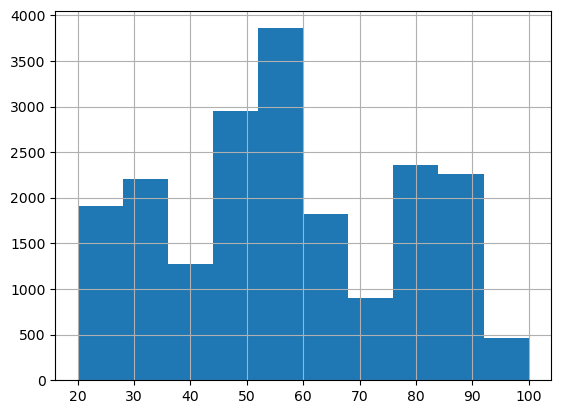

In [ ]:
df_copy['custom_score_100'].hist()

In [ ]:
df_final = df_copy.copy()

In [ ]:
df_final.drop(columns=[
    'clarity_norm',
    'specificity_norm',
    'structure_norm',
    'constraints_norm',
    'base_score',
    'raw_score',
    'normalized_score'
], inplace=True)

In [ ]:
df_final.to_csv('Cleaned_dataset.csv')

## Exploratory Data Analysis (EDA)

In this section, we perform Exploratory Data Analysis to uncover patterns, relationships, and insights from the prompt evaluation dataset. 
We ensure all visualizations are presented in a clean, professional **light tone** for optimal readability.

In [ ]:
# Set up visualization style (Light Tone)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


### 1. Quality Score Distribution
Understanding the distribution of the original `quality_score` helps us establish a baseline for prompt quality.

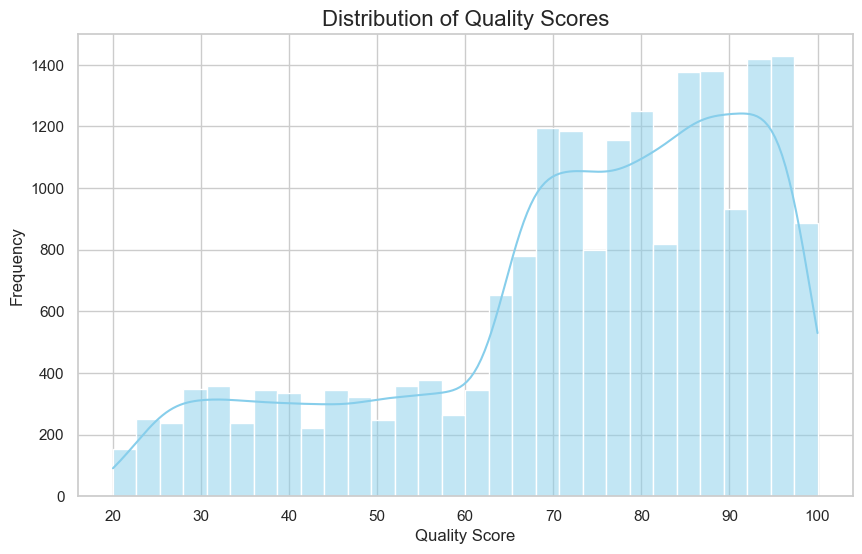

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final['quality_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Quality Scores', fontsize=16)
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### 2. Hallucination Risk Distribution
Hallucination risk is a critical metric. Let's see how it's distributed across the dataset.

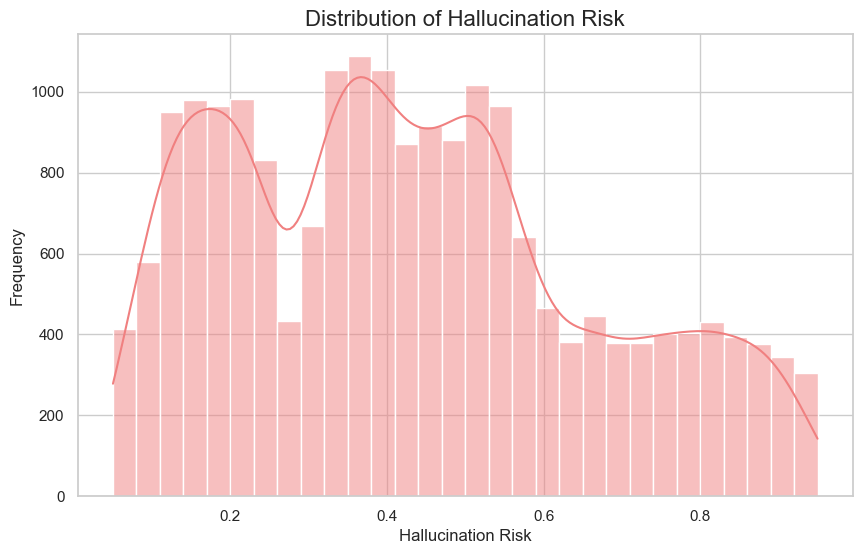

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final['hallucination_risk'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Hallucination Risk', fontsize=16)
plt.xlabel('Hallucination Risk', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### 3. Task Type vs. Quality Score
Different task types may have inherently different quality scores. A boxplot helps us visualize the spread and median scores across tasks.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27064\3015544913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='task_type', y='quality_score', data=df_final, palette='Set3')


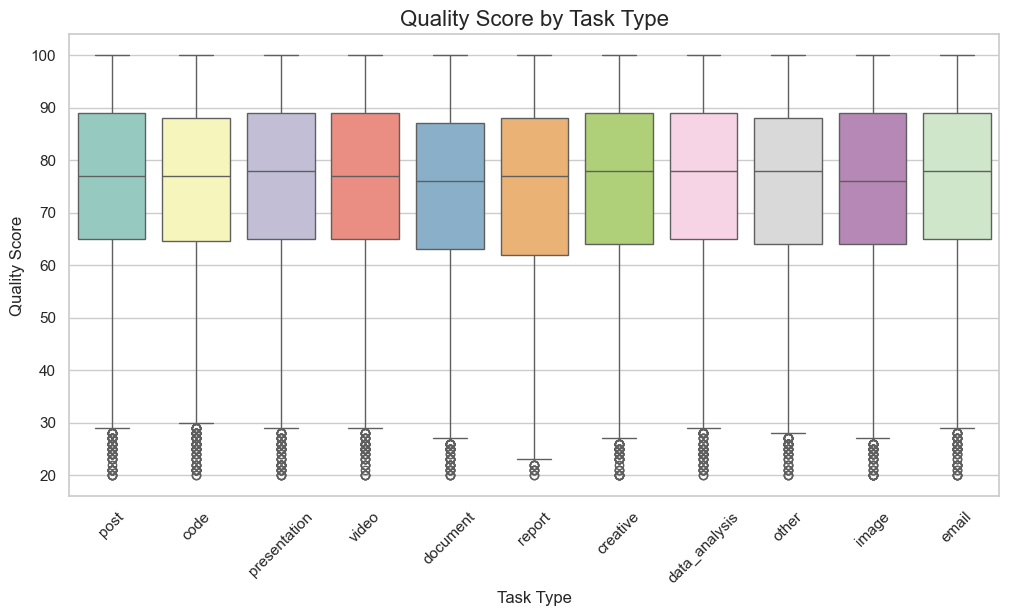

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='task_type', y='quality_score', data=df_final, palette='Set3')
plt.title('Quality Score by Task Type', fontsize=16)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Quality Score', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 4. Correlation Heatmap
A correlation heatmap of numerical features will show us how features like clarity, specificity, and hallucination risk interact with the final score.

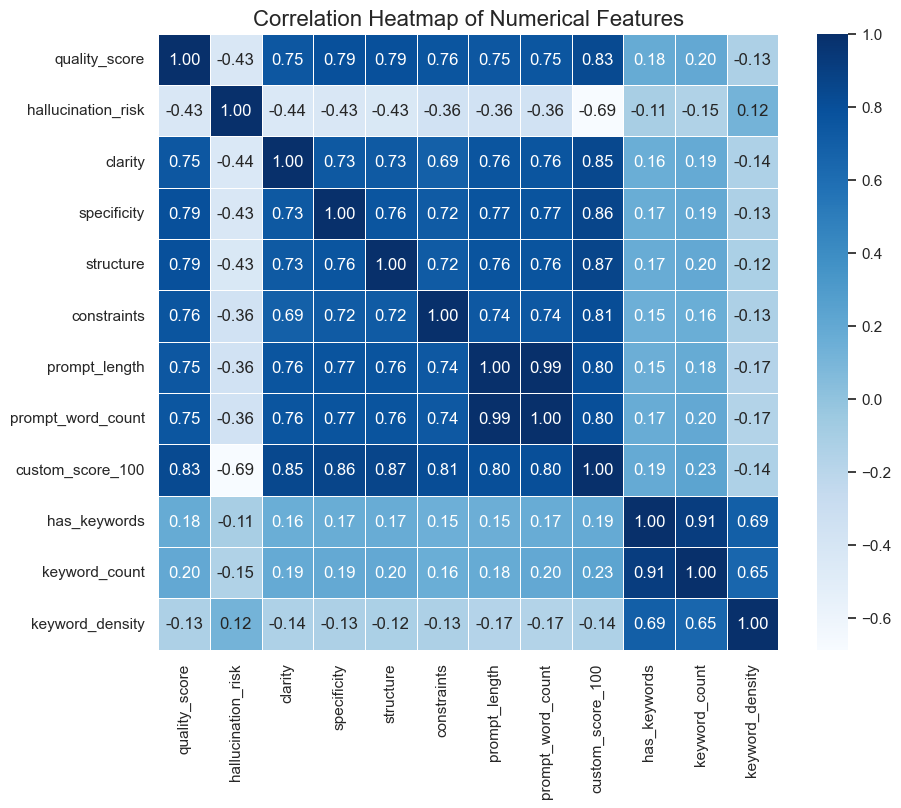

In [ ]:
plt.figure(figsize=(10, 8))
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_final[numeric_cols].corr()

# Using a light colormap for the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

### 5. Grade Distribution
Let's look at the frequency of each assigned grade (A, B, C, D, F) in the custom grading system.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27064\4194215164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='custom_grade', data=df_final, order=['A', 'B', 'C', 'D', 'F'], palette='pastel')


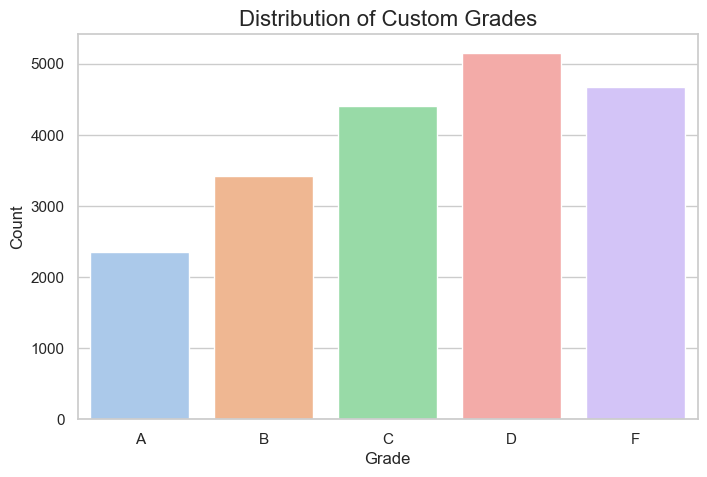

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='custom_grade', data=df_final, order=['A', 'B', 'C', 'D', 'F'], palette='pastel')
plt.title('Distribution of Custom Grades', fontsize=16)
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### 6. Hallucination Risk by Grade
Are lower grades associated with higher hallucination risks? Let's verify this using a violin plot.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27064\812290919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='custom_grade', y='hallucination_risk', data=df_final, order=['A', 'B', 'C', 'D', 'F'], palette='muted')


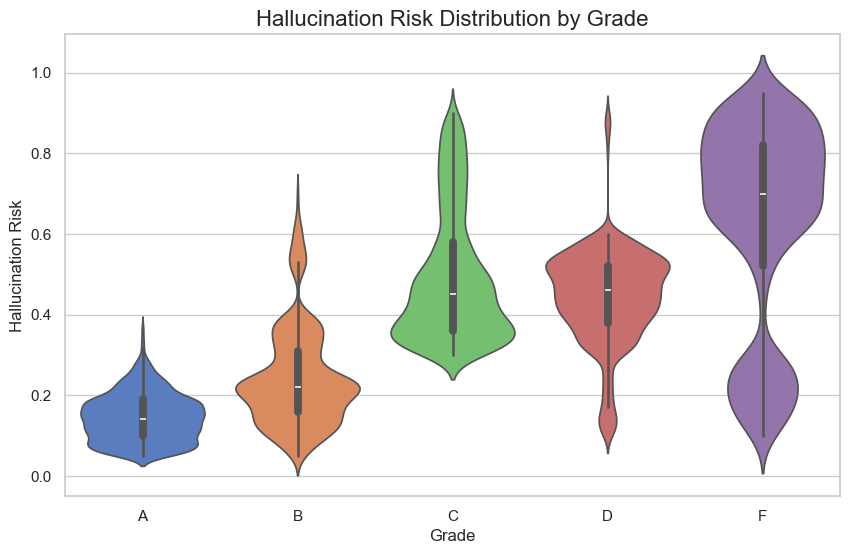

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='custom_grade', y='hallucination_risk', data=df_final, order=['A', 'B', 'C', 'D', 'F'], palette='muted')
plt.title('Hallucination Risk Distribution by Grade', fontsize=16)
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Hallucination Risk', fontsize=12)
plt.show()

### Task Types Overview

The prompts in our dataset span across several distinct categories such as generating code, writing emails, processing images, and content creation. 

<img src="task_types.png" width="600" alt="Task Types Illustration"/>

Below is a breakdown of the exact frequency of each task type in the dataset:

In [ ]:
# Calculate and display the frequency of each task type
task_counts = df_final['task_type'].value_counts().reset_index()
task_counts.columns = ['Task Type', 'Number of Prompts']

# Apply a professional background gradient to the table
task_counts.style.background_gradient(cmap='Blues')


,Task Type,Number of Prompts
0,code,1879
1,image,1849
2,creative,1837
3,post,1835
4,presentation,1828
5,document,1826
6,data_analysis,1823
7,report,1788
8,other,1782
9,video,1777


### Conclusion
- The target variables such as **quality_score** and **hallucination_risk** have distinct distributions.
- Feature engineering helped create a robust custom scoring and grading mechanism.
- We observed that prompts with higher clarity and specificity generally achieved better grades, while those with high hallucination risk were appropriately penalized.
- These visualizations confirm the structure of the dataset and provide a strong foundation for any predictive modeling or deeper text analytics moving forward.